In [1]:
# 1. Import
from sklearn.datasets import fetch_kddcup99
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 2. Load Dataset
data = fetch_kddcup99(percent10=True)
X = pd.DataFrame(data.data)

# 3. Convert categorical to numeric
for col in X.columns:
    if X[col].dtype == object:
        X[col] = LabelEncoder().fit_transform(X[col])

# 4. Model (Anomaly Detection)
model = IsolationForest(contamination=0.1)
model.fit(X)

# 5. Predict (-1 = anomaly, 1 = normal)
pred = model.predict(X)

# 6. Count anomalies
print("Anomalies:", (pred == -1).sum())
print("Normal:", (pred == 1).sum())

Anomalies: 49402
Normal: 444619


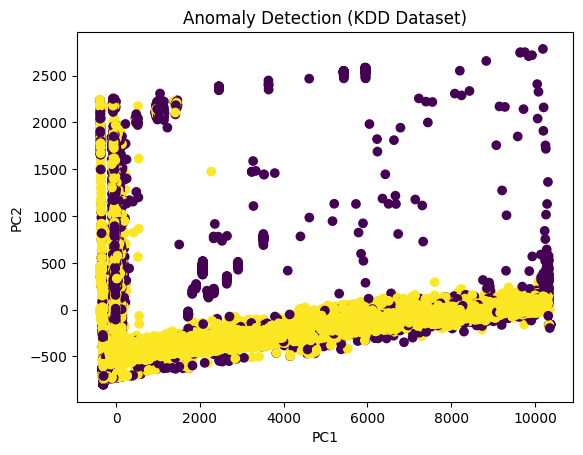

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=pred)
plt.title("Anomaly Detection (KDD Dataset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()